# Experiment 08: Analysis of Cell Coverage, Cell Radius, and Cell Splitting

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** Chapter 4 cell coverage; Chapter 6 coverage improvement and cell splitting; Master Study Notes power-radius derivation.

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Aim

To analyze cellular coverage area, cell radius, and the effect of cell splitting on area, transmitter power, and capacity.

## Objectives

- Relate cell radius to coverage area.
- Compare circular and hexagonal coverage approximations.
- Study cell splitting by reducing the cell radius.
- Apply the course power-radius relationship for a mobile-radio environment.
- Visualize the area reduction caused by splitting.

## Theory

**Cell coverage** is the geographic area in which a mobile can receive usable cellular service. The course notes list distance, obstacles/terrain, base-station power, and frequency as important factors that affect coverage.

### Coverage area

A convenient circular approximation is

$$
A_{\text{circle}}=\pi R^2
$$

For a regular hexagonal cell with center-to-vertex radius $R$,

$$
A_{\text{hex}}
=
\frac{3\sqrt{3}}{2}R^2
$$

### Cell splitting

Cell splitting replaces a congested large cell by smaller cells. If the new radius is

$$
R_2=\frac{R_1}{m}
$$

then area scales as $R^2$:

$$
\frac{A_2}{A_1}
=
\left(\frac{R_2}{R_1}\right)^2
=
\frac{1}{m^2}
$$

The course coverage derivation uses an approximate received-power behavior

$$
P_r=\alpha P_t R^{-4}
$$

in the considered mobile-radio region. If the receiver threshold is unchanged,

$$
\frac{R_2}{R_1}
=
\left(\frac{P_{t2}}{P_{t1}}\right)^{1/4}
$$

so

$$
\frac{P_{t2}}{P_{t1}}
=
\left(\frac{R_2}{R_1}\right)^4
$$

Therefore, halving the radius gives

$$
\frac{P_{t2}}{P_{t1}}
=
\left(\frac{1}{2}\right)^4
=
\frac{1}{16}
$$

for the $R^{-4}$ course model. More generally, for a path-loss exponent $n$,

$$
\frac{P_{t2}}{P_{t1}}=\left(\frac{R_2}{R_1}\right)^n
$$

and the code below uses this general form with $n=4$.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon

# Configurable parameters
original_radius_km = 2.0
split_factor = 2.0
path_loss_exponent = 4.0

split_radius_km = original_radius_km / split_factor

def circular_area(radius_km):
    return np.pi * radius_km**2

def hexagonal_area(radius_km):
    return (3 * np.sqrt(3) / 2) * radius_km**2

original_circle_area = circular_area(original_radius_km)
split_circle_area = circular_area(split_radius_km)

original_hex_area = hexagonal_area(original_radius_km)
split_hex_area = hexagonal_area(split_radius_km)

power_ratio = (split_radius_km / original_radius_km)**path_loss_exponent
power_change_db = 10 * np.log10(power_ratio)

results = pd.DataFrame({
    "Quantity": [
        "Original radius (km)",
        "Split radius (km)",
        "Original circular area (km²)",
        "Split circular area (km²)",
        "Original hexagonal area (km²)",
        "Split hexagonal area (km²)",
        "Pt_new / Pt_old",
        "Power change (dB)"
    ],
    "Value": [
        original_radius_km,
        split_radius_km,
        original_circle_area,
        split_circle_area,
        original_hex_area,
        split_hex_area,
        power_ratio,
        power_change_db
    ]
})

results

,Quantity,Value
0,Original radius (km),2.000000
1,Split radius (km),1.000000
2,Original circular area (km²),12.566371
3,Split circular area (km²),3.141593
4,Original hexagonal area (km²),10.392305
5,Split hexagonal area (km²),2.598076
6,Pt_new / Pt_old,0.062500
7,Power change (dB),-12.041200


### Interpretation of the Example

With $R_2=R_1/2$:

$$
\frac{A_2}{A_1}=\left(\frac12\right)^2=\frac14
$$

Each split cell therefore covers one quarter of the original area. Approximately four cells of this new scale are needed to cover the same idealized total area.

For the course $R^{-4}$ model:

$$
\frac{P_{t2}}{P_{t1}}=\frac{1}{16}
$$

which is approximately

$$
10\log_{10}\left(\frac1{16}\right)\approx -12.04\text{ dB}
$$

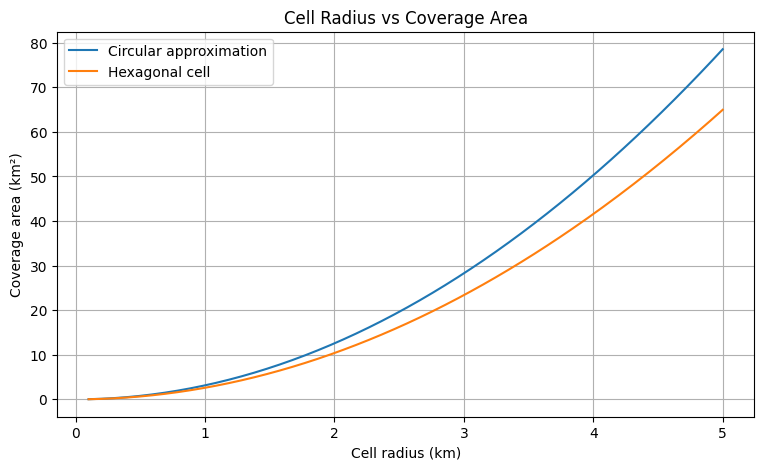

In [2]:
radii_km = np.linspace(0.1, 5.0, 250)
areas_circle = circular_area(radii_km)
areas_hex = hexagonal_area(radii_km)

plt.figure(figsize=(9, 5))
plt.plot(radii_km, areas_circle, label="Circular approximation")
plt.plot(radii_km, areas_hex, label="Hexagonal cell")
plt.xlabel("Cell radius (km)")
plt.ylabel("Coverage area (km²)")
plt.title("Cell Radius vs Coverage Area")
plt.legend()
plt.grid(True)
plt.show()

**Observation:** Coverage area grows with the square of radius, so even a moderate change in radius produces a large change in area.

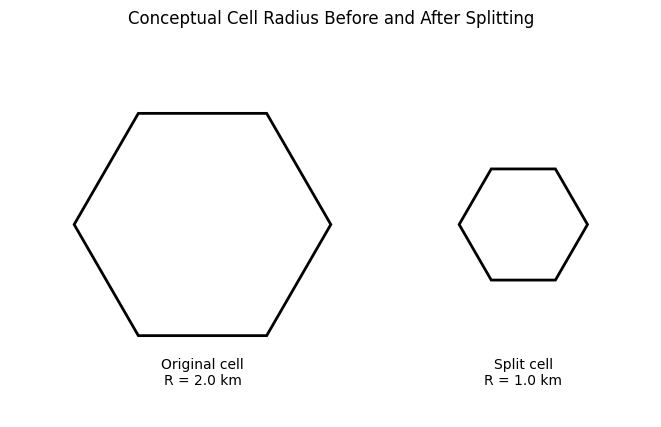

In [3]:
plt.figure(figsize=(9, 5))
ax = plt.gca()

original_hex = RegularPolygon(
    (0, 0), numVertices=6, radius=original_radius_km,
    orientation=np.pi/6, fill=False, linewidth=2
)
split_hex = RegularPolygon(
    (5, 0), numVertices=6, radius=split_radius_km,
    orientation=np.pi/6, fill=False, linewidth=2
)

ax.add_patch(original_hex)
ax.add_patch(split_hex)

plt.text(0, -2.5, f"Original cell\nR = {original_radius_km:.1f} km", ha="center")
plt.text(5, -2.5, f"Split cell\nR = {split_radius_km:.1f} km", ha="center")

plt.xlim(-3, 7)
plt.ylim(-3, 3)
plt.gca().set_aspect("equal", adjustable="box")
plt.axis("off")
plt.title("Conceptual Cell Radius Before and After Splitting")
plt.show()

## Result and Discussion

Halving cell radius reduces each idealized cell area to one quarter. Under the course $R^{-4}$ power model, the transmitter power required for the smaller cell is one sixteenth of the original value if the receive threshold remains unchanged.

Cell splitting increases capacity because the available frequency plan can be reused over a denser set of smaller cells, but it also requires more base-station infrastructure and more mobility/handover management.

## Conclusion

Cell coverage, radius, and splitting relationships were analyzed successfully. The notebook verifies the square-law area scaling and the course power-radius relationship.

## Viva Questions and Short Answers

1. **What is cell coverage?**  
   The geographic region where usable cellular service is available.

2. **How does area scale with radius?**  
   Area is proportional to $R^2$.

3. **What is cell splitting?**  
   Dividing a congested large cell into smaller cells to increase local capacity.

4. **If radius is halved, what happens to idealized cell area?**  
   It becomes one quarter.

5. **For the $R^{-4}$ model, what transmit-power ratio is needed when radius is halved?**  
   $P_{t2}/P_{t1}=1/16$.